# paper_riskDD -- 03: Cognitive Model & Convergent Evidence

Results section structure:

3. **Cognitive model results** -- bauer risk models; group differences in prior_sd / evidence_sd / RNP
4. **Convergent evidence** -- eyetracking by group; correlations between probit/cognitive model parameters and companion measures (neural precision, NPC dispersion, Corsi span, math anxiety, DEMAT)

**Depends on outputs from NB02:**
- `results/probit_sym_subwise_ss_indpoint_slope.csv`
- `results/probit_nonsym_subwise_ss_indpoint_slope.csv`

**Output files**
- `results/cogmodel_posterior_effects.csv`
- `results/convergent_correlations.csv`
- `figures/` -- paper figures

In [1]:
import sys, os, os.path as op
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az

sys.path.insert(0, os.getcwd())
from utils_riskBehav import summarize_posterior, save_posterior_effects


sns.set_theme('paper', 'white', font='helvetica', font_scale=1.2)
pal = {'Control': sns.color_palette()[0], 'Dyscalculic': sns.color_palette()[1]}

bids_folder      = '/Users/mrenke/data/ds-dnumrisk'
trace_folder     = op.join(bids_folder, 'derivatives', 'cogmodels_risk')
phenotype_folder = op.join(bids_folder, 'derivatives', 'phenotype')
out_folder       = op.join(bids_folder, 'plots_and_ims', 'paper_riskDD')

figures_folder   = op.join(out_folder, 'figures')
results_folder   = op.join(out_folder, 'results')


EXCLUDED = [32, 40, 45, 46, 50]

remove_sub_string = '_rem-32-40-45-46-50'
format = '-symbolic'

main_effect_csv = op.join(results_folder, f'cogModel_posterior_params_format{format}.csv')
main_effect_csv

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


'/Users/mrenke/data/ds-dnumrisk/plots_and_ims/paper_riskDD/results/cogModel_posterior_params_format-symbolic.csv'

---
## 3. Cognitive Model Results

Models (bauer package): `risk`, `powerLawEncodingRegression` & their regression version..

1. Model progression and selection: 
    - Posterior predictive checks... stake-size misfit 
    - Model comparison
2. Report general posterior parameters: 
    - Representational geometry
    - DD-group differences: asymmetric processing/attention ?
3. 

geometry?!

In [2]:
from numrisk.behavior_risk.utils import get_data
from os import listdir

remove_sub_list = [f'{int(s):02d}' for s in remove_sub_string[5:].split('-')]
subject_list = [subject for subject in [f[4:] for f in listdir(bids_folder) if f[0:3] == 'sub' and len(f) == 6] if subject not in remove_sub_list]

df = get_data(bids_folder,subject_list)
df = df.xs(format[1:],0, level='format')

number of subjects in dataframe: 61
Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37,
       38, 39, 41, 42, 43, 44, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59,
       60, 61, 62, 63, 64, 65, 66],
      dtype='int64', name='subject')


### 1. Model progression and selection - PPCs


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pymc/data.py:433: UserWarning: The `mutable` kwarg was not specified. Before v4.1.0 it defaulted to `pm.Data(mutable=True)`, which is equivalent to using `pm.MutableData()`. In v4.1.0 the default changed to `pm.Data(mutable=False)`, equivalent to `pm.ConstantData`. Use `pm.ConstantData`/`pm.MutableData` or pass `pm.Data(..., mutable=False/True)` to avoid this warning.
  warnings.warn(
Sampling: [ll_bernoulli]


/Users/mrenke/git/numrisk/numrisk/behavior_risk/utils_03.py:133: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,


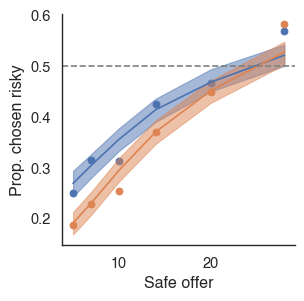

In [7]:
from numrisk.behavior_risk.utils_02 import build_model
from numrisk.behavior_risk.utils_03 import summarize_ppc # plot_ppc 

models = [ 'powerLawEncoding4_regression']#['riskKLW', 'risk', 'powerLawEncoding3', 'powerLawEncoding4']

for model_label in models:
    idata = az.from_netcdf(op.join(trace_folder, f'model-{model_label}{remove_sub_string}_format{format}_trace.netcdf'))
    model = build_model(model_label, df)
    model.build_estimation_model()

    ppc = model.ppc(idata=idata.sel(draw=slice(None, None, 10)), paradigm=df)
    groupby = ['group', 'n_safe']
    ppc_summary = summarize_ppc(ppc, groupby=groupby)
    p = df.groupby(groupby).mean(numeric_only=True)[['chose_risky']]
    ppc_summary = ppc_summary.join(p).reset_index()
    ppc_summary['Prop. chosen risky'] = ppc_summary['chose_risky']
    ppc_summary['Safe offer'] = ppc_summary['n_safe'].astype(int)

    # plotting
    fig, ax = plt.subplots(figsize=(3,3))
    x = 'Safe offer'
    for group, color in zip([0,1], [pal['Control'], pal['Dyscalculic']]):
        data = ppc_summary[ppc_summary['group'] == group]
        
        y = 'Prop. chosen risky'
        ax.scatter(data[x], data[y], color=color)

        y = 'p_predicted'
        ax.fill_between(data[x], data['hdi025'], data['hdi975'], color=color, alpha=0.5)
        ax.plot(data[x], data[y], color=color)    

    sns.despine()
    ax.axhline(0.5, color='grey', ls='--')
    ax.set(xlabel='Safe offer', ylabel='Prop. chosen risky')
    plt.savefig(op.join(figures_folder, f'ppc_{model_label}_format{format}.pdf'), bbox_inches='tight')



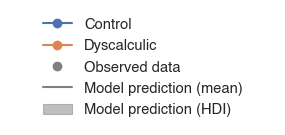

In [6]:
# legend
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

fig_leg, ax_leg = plt.subplots(figsize=(3, 1.5))
ax_leg.axis('off')

# Group color handles (filled circles for scatter)
ctrl_patch  = mlines.Line2D([], [], color=pal['Control'],     marker='o', linestyle='-',
                             linewidth=1.5, markersize=6, label='Control')
dysc_patch  = mlines.Line2D([], [], color=pal['Dyscalculic'], marker='o', linestyle='-',
                             linewidth=1.5, markersize=6, label='Dyscalculic')

# Style explanation handles (neutral gray)
scatter_handle = mlines.Line2D([], [], color='gray', marker='o', linestyle='None',
                                markersize=6, label='Observed data')
line_handle    = mlines.Line2D([], [], color='gray', linestyle='-',
                                linewidth=1.5, label='Model prediction (mean)')
shade_handle   = mpatches.Patch(color='gray', alpha=0.5, label='Model prediction (HDI)')

ax_leg.legend(handles=[ctrl_patch, dysc_patch, scatter_handle, line_handle, shade_handle],
    loc='center', frameon=False, ncol=1)
fig_leg.tight_layout()
fig_leg.savefig(op.join(figures_folder, f'ppc_legend_format.pdf'), bbox_inches='tight')


## 2. Save posterior parameter estimates

In [3]:
## model of interest: PowerLawEncoding with both ∂ev_sd_int and ∂prior_mus + regression

model_label ='powerLawEncoding4_regression' # 'risk_regression' #  #model_name = "PLE ∂ev_sd_int & ∂prior_mus + Reg"
idata = az.from_netcdf(op.join(trace_folder, f'model-{model_label}{remove_sub_string}_format{format}_trace.netcdf'))

from numrisk.behavior_risk.utils_02 import build_model
model = build_model(model_label, df)
model.build_estimation_model()

In [9]:
from utils_riskBehav import save_posterior_params

save_posterior_params(idata, model, model_name=model_label, csv_path=main_effect_csv)


Saved 7 parameters for 'powerLawEncoding3_regression' → /Users/mrenke/data/ds-dnumrisk/plots_and_ims/paper_riskDD/results/cogModel_posterior_params_format-symbolic.csv


,model,parameter,regressor,mean,ci_low,ci_high,p_gt_0
0,powerLawEncoding3_regression,alpha,Intercept,0.914883,0.871922,0.959468,1.000
1,powerLawEncoding3_regression,alpha,group,0.066499,-0.030375,0.165502,0.909
2,powerLawEncoding3_regression,evidence_sd,Intercept,3.435447,2.918830,4.014761,1.000
3,powerLawEncoding3_regression,risky_prior_mu,Intercept,5.290383,3.318964,7.286032,1.000
4,powerLawEncoding3_regression,risky_prior_mu,group,-0.028276,-1.992524,1.950841,0.484
5,powerLawEncoding3_regression,safe_prior_mu,Intercept,6.483027,4.445239,8.470523,1.000
6,powerLawEncoding3_regression,safe_prior_mu,group,0.551753,-1.397958,2.488889,0.709


## Model comparison

--> in `behavior_risk/bauerModelComp.ipynb`

In [9]:
# Natural space fix! alpha=1 set
compare_dict = {"KLW (classic NLC)": az.from_netcdf(op.join(trace_folder, f'model-riskKLW{remove_sub_string}_format{format}_trace.netcdf')),
                "NLC + asymmetric noise" : az.from_netcdf(op.join(trace_folder, f'model-risk{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE" : az.from_netcdf(op.join(trace_folder, f'model-PowerLawEncoding3{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE + asymmetric noise" : az.from_netcdf(op.join(trace_folder, f'model-PowerLawEncoding4{remove_sub_string}_format{format}_trace.netcdf')),
                }

com_res = az.compare(compare_dict)


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/numpy/core/_methods.py:48: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWa

In [10]:
com_res

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
PLE + asymmetric noise,0,-3996.519243,151.730064,0.000000,6.450523e-01,59.444886,0.000000,True,log
NLC + asymmetric noise,1,-4039.755394,98.494407,43.236151,3.549477e-01,52.806633,24.552460,False,log
PLE,2,-4075.626408,170.040517,79.107165,5.453462e-09,63.057638,7.417427,True,log
KLW (classic NLC),3,-4676.827383,104.900899,680.308140,0.000000e+00,58.251278,38.585909,True,log


In [2]:
compare_dict = {"KLW (classic NLC)": az.from_netcdf(op.join(trace_folder, f'model-riskKLW{remove_sub_string}_format{format}_trace.netcdf')),
                "NLC + asymmetric noise" : az.from_netcdf(op.join(trace_folder, f'model-risk{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE" : az.from_netcdf(op.join(trace_folder, f'model-PowerLawEncoding3{remove_sub_string}_format{format}_trace.netcdf')),
                #"PLE + asymmetric noise" : az.from_netcdf(op.join(trace_folder, f'model-PowerLawEncoding4{remove_sub_string}_format{format}_trace.netcdf')),
                }

com_res = az.compare(compare_dict)
com_res

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/numpy/core/_methods.py:48: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWa

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
NLC + asymmetric noise,0,-4039.755394,98.494407,0.000000,0.489171,52.806633,0.000000,False,log
PLE,1,-4075.626408,170.040517,35.871014,0.510829,63.057638,29.991391,True,log
KLW (classic NLC),2,-4676.827383,104.900899,637.071989,0.000000,58.251278,23.652914,True,log


### 

<Axes: xlabel='Subject (sorted by posterior mean)', ylabel='alpha'>

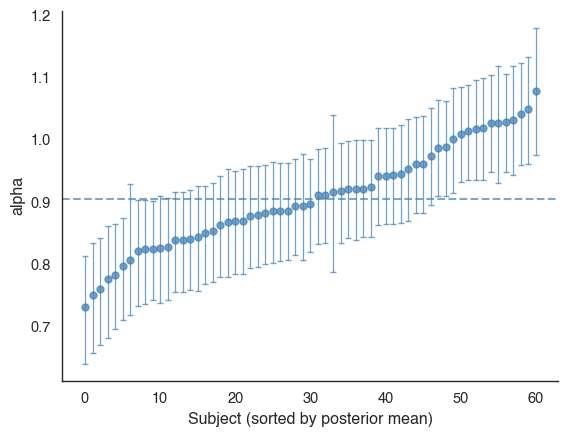

In [5]:
from bauer.utils.plotting import plot_subjectwise_parameters

model_label ='powerLawEncoding3' # 'risk_regression' #  #model_name = "PLE ∂ev_sd_int & ∂prior_mus + Reg"
idata = az.from_netcdf(op.join(trace_folder, f'model-{model_label}{remove_sub_string}_format{format}_trace.netcdf'))

plot_subjectwise_parameters(idata,'alpha')

### Save subwise params

In [ ]:
grouList = df['group'].droplevel(['session', 'trial_nr']).reset_index('subject').drop_duplicates().set_index('subject')
group_arr = grouList['group'].values # guaranteed numpy array
group_arr

# subject order matches!: grouList.reset_index()['subject'].values == idata.posterior.coords['subject']

In [ ]:
# save subjectwise asymmetry and alphas

parameter = 'alpha'

traces = idata.posterior[parameter].values  # (4, 2000, 61, 2)
# Subject-wise samples: pick intercept + slope*group for each subject
# beta0: traces[:, :, :, 0]  -> (4, 2000, 61)
# beta1: traces[:, :, :, 1]  -> (4, 2000, 61)
subject_samples = traces[:, :, :, 0] + group_arr[np.newaxis, np.newaxis, :] * traces[:, :, :, 1]
# shape: (4, 2000, 61)
subject_samples_flat = subject_samples.reshape(-1, 61)  # (8000, 61)



array([[ 0.05754285,  0.01350698],
       [ 0.0039879 ,  0.02519858],
       [ 0.34262785,  0.02023271],
       ...,
       [ 0.35673083, -0.02524341],
       [ 0.08911163,  0.00406684],
       [ 0.26213369,  0.104883  ]])

In [48]:
parameter = 'n1_evidence_sd'
traces = idata.posterior[parameter].values  # (4, 2000, 61, 2)
subject_samples = traces[:, :, :, 0] + group_arr[np.newaxis, np.newaxis, :] * traces[:, :, :, 1]
ssf_n1_evidence_sd = subject_samples.reshape(-1, 61)  # (8000, 61)

parameter = 'n2_evidence_sd'
traces = idata.posterior[parameter].values  # (4, 2000, 61, 2)
subject_samples = traces[:, :, :, 0] + group_arr[np.newaxis, np.newaxis, :] * traces[:, :, :, 1]
ssf_n2_evidence_sd = subject_samples.reshape(-1, 61)  # (8000, 61)
ssf_n_asymmetry = ssf_n1_evidence_sd - ssf_n2_evidence_sd

parameter = 'alpha'
traces = idata.posterior[parameter].values  # (4, 2000, 61, 2)
subject_samples = traces[:, :, :, 0] + group_arr[np.newaxis, np.newaxis, :] * traces[:, :, :, 1]
ssf_alpha = subject_samples.reshape(-1, 61)  # (8000, 61)


In [84]:
subwise_params = pd.DataFrame(np.array([ssf_alpha.mean(axis=0),
                            ssf_n1_evidence_sd.mean(axis=0),
                            ssf_n2_evidence_sd.mean(axis=0),
                            ssf_n_asymmetry.mean(axis=0)]).T,
                            index= grouList.reset_index()['subject'],
                            columns=['alpha', 'n1_ev_sd', 'n2_ev_sd', 'n_asym_ev_sd'])
subwise_params.index.name = 'subject'
subwise_params.to_csv(op.join(results_folder,f'cogModel_subwiseParams_model-{model_label}_format{format}.csv'))


In [94]:
risk_s = pd.read_csv(op.join(results_folder,"probit_sym_subwise_summary.csv")).set_index(['subject','group_label'])

params_comb = subwise_params.join(risk_s).join(grouList)
params_comb

,,alpha,n1_ev_sd,n2_ev_sd,n_asym_ev_sd,ind_point_map,ind_point_ss_slope,gamma_map,gamma_ss_slope,group
subject,group_label,,,,,,,,,
1,Control,0.082378,0.673719,-1.864838,2.538557,0.980567,-0.012812,4.541565,0.033833,0
2,Dyscalculic,0.233418,3.543422,-2.446285,5.989708,1.436467,-0.064109,2.362721,0.079218,1
3,Control,0.136630,3.252110,-1.841813,5.093923,2.034652,-0.097699,2.110666,0.079296,0
4,Dyscalculic,0.225274,2.693554,-2.455846,5.149400,1.264522,-0.040138,3.583629,0.086477,1
5,Control,0.202415,2.240304,-1.852342,4.092646,0.926337,-0.026881,3.403458,0.069389,0
...,...,...,...,...,...,...,...,...,...,...
62,Control,0.159370,0.918413,-1.854729,2.773142,0.755714,-0.008099,4.513681,0.011744,0
63,Control,0.170529,2.423481,-1.859035,4.282516,1.377382,-0.040596,3.340885,0.081785,0
64,Control,0.328506,2.233571,-1.858274,4.091845,0.431879,-0.014982,4.706840,0.090888,0


In [108]:
var_comb_of_interest = (['gamma_ss_slope','ind_point_ss_slope'],
                        ['ind_point_ss_slope', 'alpha'], 
                        ['ind_point_ss_slope', 'n_asym_ev_sd'], 
                        ['ind_point_ss_slope', 'n1_ev_sd'], 
                        ['gamma_ss_slope', 'alpha'], 
                        ['gamma_ss_slope', 'n_asym_ev_sd'], 
                        ['gamma_ss_slope', 'n1_ev_sd'])


In [119]:
import pingouin

rows = []
for x_var, y_var in var_comb_of_interest:
    cor = pingouin.corr(tmp[y_var], tmp[x_var], method='spearman')
    rows.append({
        'var1': x_var,
        'var2': y_var,
        'r': np.round(cor['r'].iloc[0], 2),
        'p': np.round(cor['p-val'].iloc[0], 3)
    })

corr_results = pd.DataFrame(rows)
corr_results.to_csv(op.join(results_folder, 'correlations_probit-cognitiveModel.csv'))


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_82225/24831032.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_ = np.round(cor['r'][0], 2)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_82225/24831032.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = np.round(cor['p-val'][0], 3)


TypeError: concat() takes 1 positional argument but 2 were given

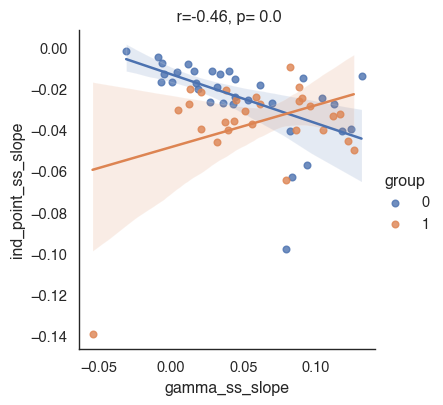

In [ ]:
# correlate all variables in the dataframe
import itertools

tmp = params_comb# .reset_index() # reset index to have 'group' as a column for hue in the plot

rows = []
for x_var, y_var in var_comb_of_interest: # itertools.combinations(vars, 2):
    cor = pingouin.corr(tmp[y_var], tmp [x_var], method = 'spearman') #defautl: two -sided & pearson
    r_ = np.round(cor['r'][0], 2)
    p = np.round(cor['p-val'][0], 3)
    fig = sns.lmplot(x=x_var, y=y_var, data=tmp, hue='group',height=4) #, hue='group' hue='group',
    fig.set(title=f' r={r_}, p= {p}') 

    corr_results = pd.concat(corr_results, [x_var,y_var,r_, p])
    #plt.savefig(op.join(plot_folder, f'corr_groups-both_{x_var}_vs_{y_var}.png'), dpi=300, bbox_inches='tight')

In [97]:
params_comb.columns

Index(['alpha', 'n1_ev_sd', 'n2_ev_sd', 'n_asym_ev_sd', 'ind_point_map',
       'ind_point_ss_slope', 'gamma_map', 'gamma_ss_slope', 'group'],
      dtype='object')

In [112]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#formula = f'{dep_var} ~ {ind_var} + group'
formula = 'ind_point_ss_slope ~  alpha + n1_ev_sd ' # alpha + n_asym_ev_sd +
result = sm.formula.ols(formula=formula, data=params_comb.reset_index()).fit()

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     ind_point_ss_slope   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.337
Method:                 Least Squares   F-statistic:                     16.28
Date:                Fri, 22 May 2026   Prob (F-statistic):           2.44e-06
Time:                        13:40:01   Log-Likelihood:                 161.28
No. Observations:                  61   AIC:                            -316.6
Df Residuals:                      58   BIC:                            -310.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0097      0.008      1.274      0.208      -0.006       0.025
alpha          0.0161      0.019      0.839      0.405      -0.022       0.055
n1_ev_sd      -0.0183      0.003     -5.682      0.000      -0.025      -0.012
==============================================================================
Omnibus:                       66.514   Durbin-Watson:                   1.801
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              598.532
Skew:                          -2.944   Prob(JB):                    1.07e-130
Kurtosis:                      17.171   Cond. No.                         22.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [117]:
result._attrs

{'chisq': 'columns',
 'sresid': 'rows',
 'weights': 'rows',
 'wresid': 'rows',
 'bcov_unscaled': 'cov',
 'bcov_scaled': 'cov',
 'HC0_se': 'columns',
 'HC1_se': 'columns',
 'HC2_se': 'columns',
 'HC3_se': 'columns',
 'norm_resid': 'rows'}

### Visualize PLE: 
`r~n` & `sd(n)~n` curves

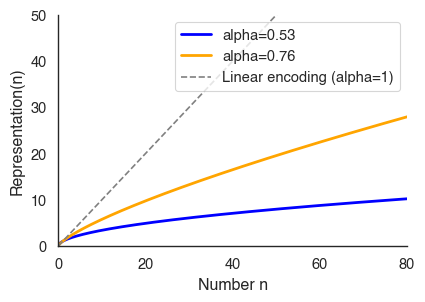

In [3]:
n = np.linspace(0, 100, 1000)

alpha_ns = 0.53
alpha_s = 0.76

r_ns = n**alpha_ns 
r_s = n**alpha_s

fig, ax = plt.subplots(figsize=(4.5,3))
ax.plot(n, r_ns, color='blue', label=f'alpha={alpha_ns:.2f}', linewidth=2)
ax.plot(n, r_s, color='orange', label=f'alpha={alpha_s:.2f}', linewidth=2)

# diagonal line for reference
ax.plot(n, n, color='grey', ls='--', label='Linear encoding (alpha=1)')
sns.despine()
ax.set(xlabel='Number n', ylabel='Representation(n)', ylim=(0, 50), xlim=(0, 80))
ax.legend(loc='upper right')

from `_grp_encoding` in `plot_sd_curve`:

**SD(n) = sd(r) / (alpha * n^(alpha - 1))**

derived from constant SD in representation space + inverse of the power-law derivative 
`sd(r) = const`
`dr/dn = alpha * n^(alpha-1))`

A small perturbation in representation `dr` maps back to number space via the inverse encoding. By the chain rule
`dn = dr / (dr/dn)` --> So noise in number space scales as:
`SD(n) = SD(r) / (dr/dn)`

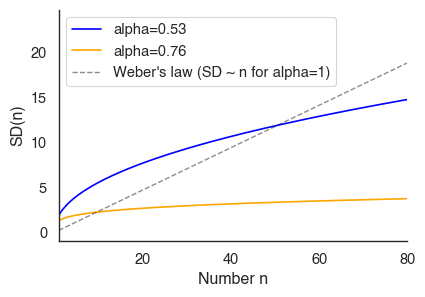

In [4]:
n = np.linspace(1, 100, 1000)  # start at 1 to avoid n=0

alpha_ns = 0.53
alpha_s  = 0.76
sd_rep = 1.0  # unit SD in representation space (illustrative)

# SD(n) = dr/dn  = sd_rep / (alpha * n^(alpha-1))
sd_n_ns = sd_rep / (alpha_ns * n ** (alpha_ns - 1))
sd_n_s  = sd_rep / (alpha_s  * n ** (alpha_s  - 1))

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.plot(n, sd_n_ns, color='blue',   label=f'alpha={alpha_ns:.2f}')
ax.plot(n, sd_n_s,  color='orange', label=f'alpha={alpha_s:.2f}')

# Weber reference: SD ∝ n
mid = len(n) // 2
ax.plot(n, sd_n_ns[mid] * n / n[mid], 'k--', lw=1, alpha=0.5, label="Weber's law (SD ~ n for alpha=1)")

sns.despine()
ax.set(xlabel='Number n', ylabel='SD(n)', xlim=(1, 80))
ax.legend(loc='upper left')


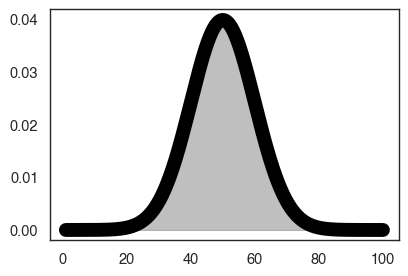

In [6]:
from scipy import stats as ss

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.plot(n, ss.norm.pdf(n, loc=50, scale=10), color='black', linewidth=10)
ax.fill_between(n, ss.norm.pdf(n, loc=50, scale=10), color='grey', alpha=0.5)

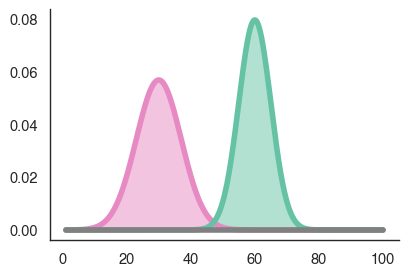

In [7]:
n = np.linspace(1, 100, 1000)  # start at 1 to avoid n=0
palette = sns.color_palette('Set2', 4)

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.plot(n, ss.norm.pdf(n, loc=30, scale=7), color=palette[3], linewidth=4)
ax.fill_between(n, ss.norm.pdf(n, loc=30, scale=7), color=palette[3], alpha=0.5)

ax.plot(n, ss.norm.pdf(n, loc=60, scale=5), color=palette[0], linewidth=4)
ax.fill_between(n, ss.norm.pdf(n, loc=60, scale=5), color=palette[0], alpha=0.5)

ax.plot(n,np.zeros_like(n), color='grey',  linewidth=4)
sns.despine()

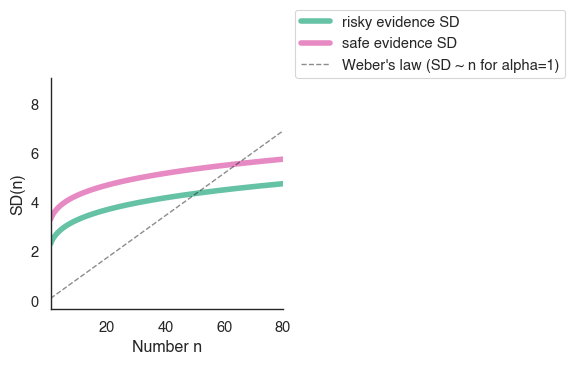

In [10]:
# SD(n) = dr/dn  = sd_rep / (alpha * n^(alpha-1))
sd_n_risky = 1 + (sd_rep / (alpha_s * n ** (alpha_s - 1)))
sd_n_safe  = 2 + (sd_rep / (alpha_s  * n ** (alpha_s  - 1)))

fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(n, sd_n_risky, color=palette[0],   label='risky evidence SD', linewidth=4)
ax.plot(n, sd_n_safe,  color=palette[3], label='safe evidence SD', linewidth=4)

# Weber reference: SD ∝ n
mid = len(n) // 2
ax.plot(n, sd_n_risky[mid] * n / n[mid], 'k--', lw=1, alpha=0.5, label="Weber's law (SD ~ n for alpha=1)")
sns.despine()
ax.set(xlabel='Number n', ylabel='SD(n)', xlim=(1, 80))
ax.legend(bbox_to_anchor=(1.05, 1), borderaxespad=0.)



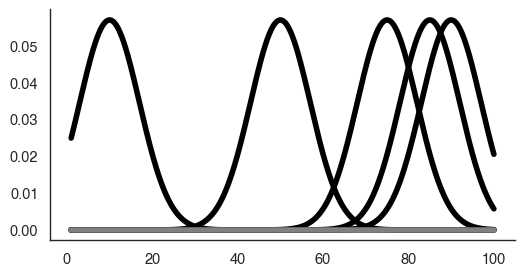

In [19]:
n = np.linspace(1, 100, 1000)  # start at 1 to avoid n=0
palette = sns.color_palette('Set2', 4)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(n, ss.norm.pdf(n, loc=10, scale=7), linewidth=4, c='black')
ax.plot(n, ss.norm.pdf(n, loc=50, scale=7), linewidth=4,  c='black')

ax.plot(n, ss.norm.pdf(n, loc=75, scale=7), linewidth=4, c='black')
ax.plot(n, ss.norm.pdf(n, loc=85, scale=7), linewidth=4,  c='black')
ax.plot(n, ss.norm.pdf(n, loc=90, scale=7), linewidth=4,  c='black')

ax.plot(n,np.zeros_like(n), color='grey',  linewidth=4)
sns.despine()

In [ ]:
n = np.linspace(1, 100, 1000)  # start at 1 to avoid n=0
palette = sns.color_palette('Set2', 4)

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.plot(n, ss.norm.pdf(n, loc=30, scale=7), color=palette[3], linewidth=4)
ax.fill_between(n, ss.norm.pdf(n, loc=30, scale=7), color=palette[3], alpha=0.5)

ax.plot(n, ss.norm.pdf(n, loc=60, scale=5), color=palette[0], linewidth=4)
ax.fill_between(n, ss.norm.pdf(n, loc=60, scale=5), color=palette[0], alpha=0.5)

ax.plot(n,np.zeros_like(n), color='grey',  linewidth=4)
sns.despine()